<a href="https://colab.research.google.com/github/rka0285058-afk/Health/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

# URL of the dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Define the local file name
local_file_name = 'heart_disease.csv'

# Download the file
try:
    response = requests.get(dataset_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(local_file_name, 'wb') as f:
        f.write(response.content)
    print(f"Successfully downloaded '{local_file_name}' from {dataset_url}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the dataset: {e}")

Successfully downloaded 'heart_disease.csv' from https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data


### Simulating New Patient Predictions

We can use our trained `LogisticRegression` model to predict the heart disease status for new, hypothetical patients. Below is a function that takes a new patient's features as input and returns the model's prediction.

In [ ]:
import pandas as pd

def predict_new_patient_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, model_to_use):
    """
    Predicts heart disease for a new patient based on their features.

    Args:
        age (float): age in years
        sex (float): sex (1 = male; 0 = female)
        cp (float): chest pain type (1-4)
        trestbps (float): resting blood pressure (mm Hg)
        chol (float): serum cholestoral in mg/dl
        fbs (float): fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
        restecg (float): resting electrocardiographic results (0-2)
        thalach (float): maximum heart rate achieved
        exang (float): exercise induced angina (1 = yes; 0 = no)
        oldpeak (float): ST depression induced by exercise relative to rest
        slope (float): the slope of the peak exercise ST segment
        ca (float): number of major vessels (0-3) colored by flourosopy
        thal (float): 3 = normal; 6 = fixed defect; 7 = reversable defect
        model_to_use: The trained machine learning model to use for prediction.

    Returns:
        int: Predicted heart disease status (0 = no disease, 1 = disease).
    """
    # Ensure the input features are in the same order as the training data (X_train)
    # The columns of X_train were: 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
    new_patient_data = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                                      columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    # Make prediction
    prediction = model_to_use.predict(new_patient_data)

    return prediction[0]

print("Simulation function 'predict_new_patient_heart_disease' created.")

Simulation function 'predict_new_patient_heart_disease' created.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import requests # Import requests for downloading the dataset

# This block ensures logistic_regression_model and X_train are defined
# for subsequent cells that depend on them, especially in cases of kernel resets
# or non-linear execution.

if 'logistic_regression_model' not in globals() or 'X_train' not in globals():
    print("Re-running essential setup for logistic regression model...")

    # Define column names as the dataset usually comes without a header
    column_names = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
        'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
    ]

    # URL of the dataset
    dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    # Define the local file name
    local_file_name = 'heart_disease.csv'

    # Download the file to ensure it's available
    try:
        response = requests.get(dataset_url)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(local_file_name, 'wb') as f:
            f.write(response.content)
        # print(f"Successfully ensured '{local_file_name}' is available from {dataset_url}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the dataset: {e}")

    # Load the dataset.
    try:
        df = pd.read_csv(local_file_name, names=column_names, na_values='?')
    except FileNotFoundError:
        print("Error: 'heart_disease.csv' not found even after download attempt. Please check URL or file path.")
        df = pd.DataFrame()

    # Calculate the median for 'ca' and 'thal' columns and fill missing values
    if not df.empty:
        median_ca = df['ca'].median()
        median_thal = df['thal'].median()
        df['ca'] = df['ca'].fillna(median_ca)
        df['thal'] = df['thal'].fillna(median_thal)

        # Transform the target variable 'num' into a binary outcome
        df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
        df = df.drop('num', axis=1)

        # Separate features (X) and target (y)
        X = df.drop('target', axis=1)
        y = df['target']

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Initialize and Train the Logistic Regression model
        logistic_regression_model = LogisticRegression(solver='liblinear', random_state=42)
        logistic_regression_model.fit(X_train, y_train)
        print("Logistic Regression model and data dependencies re-initialized.")
    else:
        print("DataFrame is empty, cannot proceed with model training.")
        logistic_regression_model = None # Ensure model is None if df is empty
        X_train = pd.DataFrame() # Ensure X_train is empty if df is empty

else:
    print("Logistic Regression model and X_train already defined. Skipping re-initialization.")


Re-running essential setup for logistic regression model...
Logistic Regression model and data dependencies re-initialized.


### Example Simulation

Let's try an example. Here, we'll simulate a patient with certain characteristics and see the prediction.

In [ ]:
# Example patient features:
# (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)
example_patient = (
    55,    # age
    1,     # sex (male)
    3,     # cp (chest pain type)
    140,   # trestbps (resting blood pressure)
    200,   # chol (serum cholestoral)
    0,     # fbs (fasting blood sugar < 120)
    1,     # restecg (normal ECG)
    150,   # thalach (max heart rate achieved)
    0,     # exang (no exercise induced angina)
    1.0,   # oldpeak
    2,     # slope
    0,     # ca (number of major vessels)
    3      # thal (normal)
)

predicted_status = predict_new_patient_heart_disease(*example_patient, model_to_use=logistic_regression_model)

if predicted_status == 1:
    print(f"The model predicts that this patient is likely to have heart disease.")
else:
    print(f"The model predicts that this patient is unlikely to have heart disease.")

The model predicts that this patient is unlikely to have heart disease.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
logistic_regression_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
logistic_regression_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
# Make predictions on the test set
y_pred = logistic_regression_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9016
Precision: 0.9062
Recall: 0.9062
F1-Score: 0.9062

Confusion Matrix:
[[26  3]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
# Using a 80/20 split and a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (242, 13)
Shape of X_test: (61, 13)
Shape of y_train: (242,)
Shape of y_test: (61,)


In [ ]:
print("First 5 rows of the DataFrame with the 'target' column:")
display(df.head())

First 5 rows of the DataFrame with the 'target' column:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
from google.colab import userdata

hf_token = userdata.get('AI') # Assuming your token is named 'AI' as in the notebook

if hf_token is not None:
    print("Hugging Face token 'AI' successfully loaded from Colab secrets.")
else:
    print("Hugging Face token 'AI' not found or not accessible in Colab secrets. Please ensure it's set up correctly.")

Hugging Face token 'AI' successfully loaded from Colab secrets.


In [ ]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

# Calculate the median for 'ca' and 'thal' columns
median_ca = df['ca'].median()
median_thal = df['thal'].median()

# Fill missing values with the calculated medians
df['ca'] = df['ca'].fillna(median_ca)
df['thal'] = df['thal'].fillna(median_thal)

print('\nMissing values after imputation:')
display(df.isnull().sum())

Missing values in each column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Missing values after imputation:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
import pandas as pd

# Define column names as the dataset usually comes without a header
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Load the dataset. Assuming the file is named 'heart_disease.csv' and is in the Colab environment.
# If you uploaded it to '/tmp/', change the path accordingly.
try:
    df = pd.read_csv('heart_disease.csv', names=column_names, na_values='?')
except FileNotFoundError:
    print("Error: 'heart_disease.csv' not found. Please make sure you have uploaded the file or provided the correct path.")
    df = pd.DataFrame()

# Display the first 5 rows of the DataFrame
if not df.empty:
    display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Interactive Patient Prediction Window

Let's create an interactive widget to easily input patient parameters and get predictions from our trained model. This will allow you to quickly test different scenarios.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Define the widgets for each input parameter
# You can adjust min/max/step values based on typical ranges for each feature

age_widget = widgets.IntSlider(min=29, max=77, step=1, value=50, description='Age:')
sex_widget = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], value=1, description='Sex:')
cp_widget = widgets.IntSlider(min=1, max=4, step=1, value=3, description='Chest Pain Type (cp):')
trestbps_widget = widgets.IntSlider(min=90, max=200, step=1, value=120, description='Resting BP (trestbps):')
chol_widget = widgets.IntSlider(min=126, max=564, step=1, value=200, description='Cholesterol (chol):')
fbs_widget = widgets.Dropdown(options=[('True (>120 mg/dl)', 1), ('False (<120 mg/dl)', 0)], value=0, description='Fasting BS (fbs):')
restecg_widget = widgets.IntSlider(min=0, max=2, step=1, value=1, description='Resting ECG (restecg):')
thalach_widget = widgets.IntSlider(min=71, max=202, step=1, value=150, description='Max HR (thalach):')
exang_widget = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], value=0, description='Exercise Angina (exang):')
oldpeak_widget = widgets.FloatSlider(min=0.0, max=6.2, step=0.1, value=1.0, description='Oldpeak:')
slope_widget = widgets.IntSlider(min=1, max=3, step=1, value=2, description='Slope:')
ca_widget = widgets.IntSlider(min=0, max=3, step=1, value=0, description='Num Major Vessels (ca):')
thal_widget = widgets.Dropdown(options=[('Normal', 3), ('Fixed Defect', 6), ('Reversable Defect', 7)], value=3, description='Thal:')

predict_button = widgets.Button(description='Predict Heart Disease & Explain')
output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        clear_output(wait=True)
        # Get values from widgets
        age = age_widget.value
        sex = sex_widget.value
        cp = cp_widget.value
        trestbps = trestbps_widget.value
        chol = chol_widget.value
        fbs = fbs_widget.value
        restecg = restecg_widget.value
        thalach = thalach_widget.value
        exang = exang_widget.value
        oldpeak = oldpeak_widget.value
        slope = slope_widget.value
        ca = ca_widget.value
        thal = thal_widget.value

        # Prepare data for prediction (similar to predict_new_patient_heart_disease function)
        new_patient_data = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                                          columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

        # Make prediction and get probability
        predicted_status = logistic_regression_model.predict(new_patient_data)[0]
        predicted_probability = logistic_regression_model.predict_proba(new_patient_data)[:, 1][0]

        # Display the prediction result and probability
        if predicted_status == 1:
            print(f"Prediction: This patient is likely to have heart disease. (Probability: {predicted_probability:.4f})")
        else:
            print(f"Prediction: This patient is unlikely to have heart disease. (Probability: {predicted_probability:.4f})")

        # --- SHAP Explanation ---
        print("\n--- SHAP Explanation ---")
        try:
            # Ensure X_train is defined for the explainer background
            if 'X_train' not in globals():
                print("Error: X_train not found. Please ensure data loading and splitting cells are run.")
                return

            # Initialize SHAP explainer with the trained model and background data
            # Using X_train as background for the explainer
            explainer = shap.Explainer(logistic_regression_model, X_train)

            # Calculate SHAP values for the current new patient data
            shap_values = explainer.shap_values(new_patient_data)

            # Display the waterfall plot
            shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=new_patient_data.iloc[0]), show=False)
            plt.title('SHAP Waterfall Plot for Current Patient Prediction')
            plt.show()
            plt.close() # Close the plot to prevent it from displaying again if not needed

        except Exception as e:
            print(f"Error generating SHAP explanation: {e}")

# Attach the click event handler to the button
predict_button.on_click(on_button_click)

# Arrange widgets in a vertical box
input_widgets = widgets.VBox([
    age_widget,
    sex_widget,
    cp_widget,
    trestbps_widget,
    chol_widget,
    fbs_widget,
    restecg_widget,
    thalach_widget,
    exang_widget,
    oldpeak_widget,
    slope_widget,
    ca_widget,
    thal_widget,
    predict_button
])

# Display the input widgets and the output area
display(input_widgets, output_area)

Output()

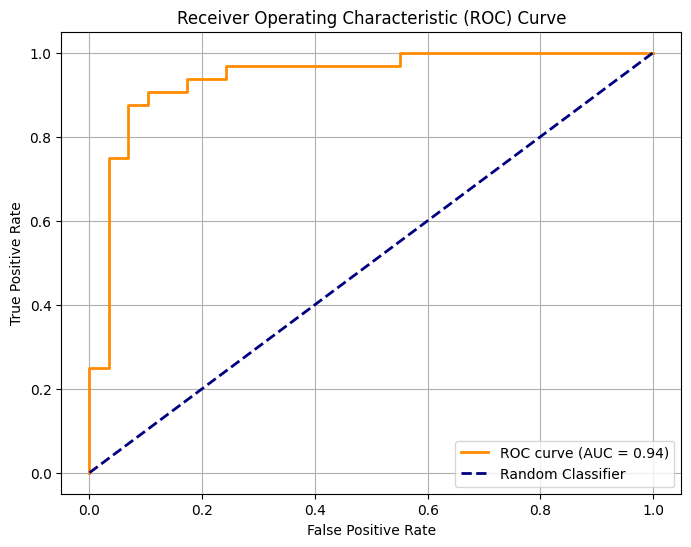

The Area Under the ROC Curve (AUC) is: 0.9407


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = logistic_regression_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"The Area Under the ROC Curve (AUC) is: {roc_auc:.4f}")

### Explaining a Single Prediction with SHAP (Logistic Regression)

To understand *why* the Logistic Regression model made a particular prediction, we can use SHAP (SHapley Additive exPlanations). SHAP values tell us how much each feature contributes to pushing the model's output from the base value (average prediction) to the actual prediction for that instance. This can help bridge the gap between model output and human understanding.

First, we need to install the `shap` library.

In [ ]:
pip install shap

Successfully ensured 'heart_disease.csv' is available from https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Predicted probability of heart disease for example patient: 0.2135


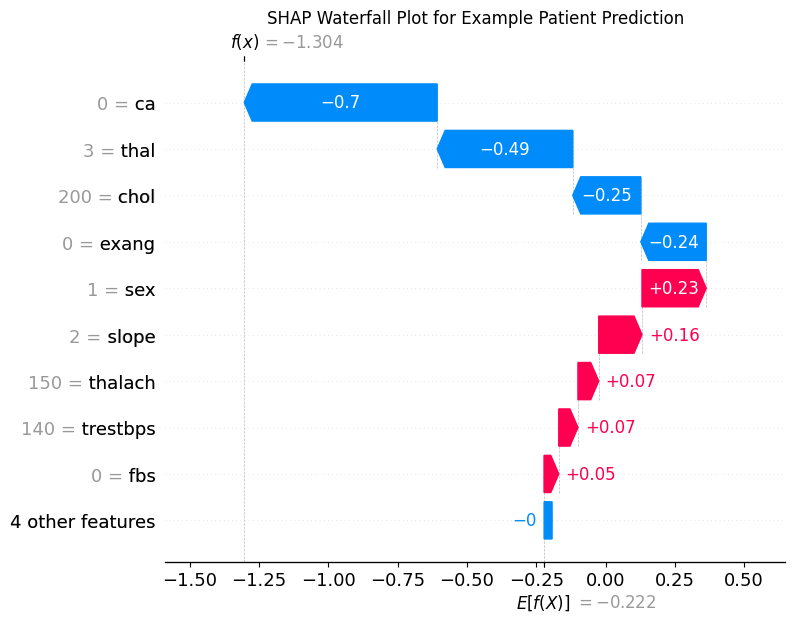

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import requests # Import requests for downloading the dataset

# --- Re-running necessary setup to define model and X_train ---

# Define column names as the dataset usually comes without a header
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# URL of the dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
# Define the local file name
local_file_name = 'heart_disease.csv'

# Download the file to ensure it's available
try:
    response = requests.get(dataset_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(local_file_name, 'wb') as f:
        f.write(response.content)
    print(f"Successfully ensured '{local_file_name}' is available from {dataset_url}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the dataset: {e}")

# Load the dataset.
try:
    df = pd.read_csv('heart_disease.csv', names=column_names, na_values='?')
except FileNotFoundError:
    print("Error: 'heart_disease.csv' not found even after download attempt. Please check URL or file path.")
    df = pd.DataFrame()

# Calculate the median for 'ca' and 'thal' columns and fill missing values
if not df.empty:
    median_ca = df['ca'].median()
    median_thal = df['thal'].median()
    df['ca'] = df['ca'].fillna(median_ca)
    df['thal'] = df['thal'].fillna(median_thal)

    # Transform the target variable 'num' into a binary outcome
    df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
    df = df.drop('num', axis=1)

    # Separate features (X) and target (y)
    X = df.drop('target', axis=1)
    y = df['target']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and Train the Logistic Regression model
    logistic_regression_model_for_shap = LogisticRegression(solver='liblinear', random_state=42)
    logistic_regression_model_for_shap.fit(X_train, y_train)
else:
    print("DataFrame is empty, cannot proceed with model training or SHAP explanations.")
    logistic_regression_model_for_shap = None # Ensure model is None if df is empty
    X_train = pd.DataFrame() # Ensure X_train is empty if df is empty

# --- End of setup re-run ---

if logistic_regression_model_for_shap is not None and not X_train.empty:
    # Recreate the example patient DataFrame to match the model's input format
    example_patient_df = pd.DataFrame([[
        55,    # age
        1,     # sex (male)
        3,     # cp (chest pain type)
        140,   # trestbps (resting blood pressure)
        200,   # chol (serum cholestoral)
        0,     # fbs (fasting blood sugar < 120)
        1,     # restecg (normal ECG)
        150,   # thalach (max heart rate achieved)
        0,     # exang (no exercise induced angina)
        1.0,   # oldpeak
        2,     # slope
        0,     # ca (number of major vessels)
        3      # thal (normal)
    ]],
        columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    # Initialize a SHAP explainer for the Logistic Regression model
    explainer = shap.Explainer(logistic_regression_model_for_shap, X_train)

    # Calculate SHAP values for the example patient
    shap_values = explainer.shap_values(example_patient_df)

    # Visualize the explanation for the example patient's prediction
    print(f"Predicted probability of heart disease for example patient: {logistic_regression_model_for_shap.predict_proba(example_patient_df)[:, 1][0]:.4f}")
    shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=example_patient_df.iloc[0]), show=False)
    plt.title('SHAP Waterfall Plot for Example Patient Prediction')
    plt.show()
else:
    print("Model or training data not available for SHAP explanation due to previous errors.")

The waterfall plot above illustrates how each feature contributes to the individual prediction for the example patient. The base value represents the average model output, and each feature either pushes the prediction higher (towards heart disease) or lower (away from heart disease), culminating in the final prediction for that patient.

### Training and Evaluating a Random Forest Classifier

Let's train a Random Forest model on our dataset and evaluate its performance using the same metrics as the Logistic Regression model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
random_forest_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest Model training complete.")

Random Forest Model training complete.


In [ ]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

### Feature Importance for Logistic Regression

For Logistic Regression, we can interpret the absolute magnitude of the coefficients as an indicator of feature importance. Larger absolute coefficients suggest a stronger impact on the predicted probability of heart disease.

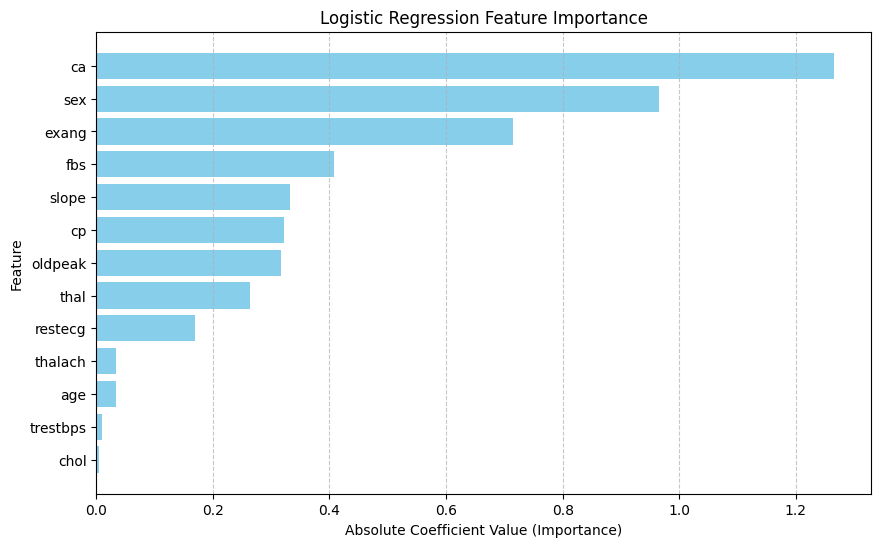

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names from X_train
feature_names = X_train.columns

# Get coefficients from the trained Logistic Regression model
logistic_coefficients = logistic_regression_model.coef_[0]

# Create a DataFrame for better visualization
log_reg_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(logistic_coefficients)
})

# Sort by importance
log_reg_importance_df = log_reg_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(log_reg_importance_df['Feature'], log_reg_importance_df['Importance'], color='skyblue')
plt.xlabel('Absolute Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Importance')
plt.gca().invert_yaxis() # Display most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Feature Importance for Random Forest Classifier

For tree-based models like Random Forest, feature importance is typically derived from the average reduction in impurity (e.g., Gini impurity) contributed by each feature across all trees in the forest. A higher value indicates a more important feature.

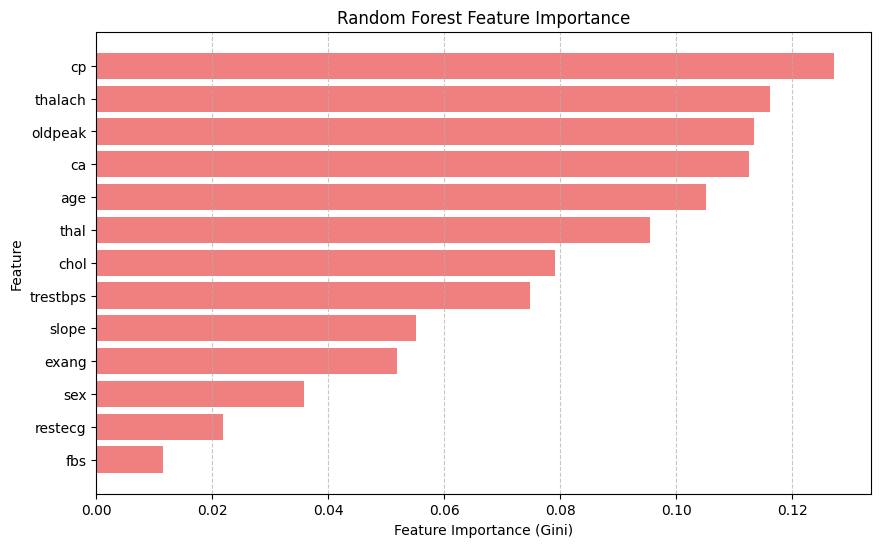

In [ ]:
# Get feature importances from the trained Random Forest model
rf_importances = random_forest_model.feature_importances_

# Create a DataFrame for better visualization
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
})

# Sort by importance
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='lightcoral')
plt.xlabel('Feature Importance (Gini)')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis() # Display most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### AI Tool: Simplifying Medical Information with Gemma

To address the real-world challenge of democratizing knowledge and bridging the gap between medical professionals and patients, we can leverage Gemma models to simplify complex medical jargon into easily understandable language. This tool will take a medical description and generate a patient-friendly explanation.

First, we need to install the `transformers` library, which provides access to Gemma models, and `accelerate` for optimized performance.

In [ ]:
pip install transformers accelerate

Next, we'll load a Gemma model and its tokenizer. We'll use `gemma-2b-it` (instruction-tuned 2 billion parameter model) as it's efficient for explanatory tasks. We also need to set up our Hugging Face token.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from google.colab import userdata

# NOTE: You need to authenticate with Hugging Face to use Gemma models.
# Please add your token to Colab secrets and access it via `userdata.get('HF_TOKEN')`.
# Ensure 'HF_TOKEN' is set as a secret with notebook access enabled.
hf_token = userdata.get('AI') # Removed 'None' from here

if hf_token is None:
    print("Error: Hugging Face token (HF_TOKEN) not found in Colab secrets. Please set it up.")
    # Optionally, you can prompt for login if you want interactive authentication
    # !huggingface-cli login
else:
    print("Hugging Face token found. Attempting to load Gemma model...")
    tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b-it", token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        "google/gemma-2b-it",
        device_map="auto",
        torch_dtype=torch.bfloat16, # Use bfloat16 for efficiency if your GPU supports it
        token=hf_token
    )
    print("Gemma model and tokenizer loaded successfully.")


Hugging Face token found. Attempting to load Gemma model...


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Gemma model and tokenizer loaded successfully.


Now, let's define a function that takes a medical text and uses the Gemma model to rephrase it in simpler terms.

In [ ]:
def simplify_medical_text(medical_text):
    """
    Uses the Gemma model to simplify a given medical text for a general audience.
    """
    prompt = f"""Rewrite the following medical explanation in simple, easy-to-understand terms for a patient, avoiding technical jargon:

    {medical_text}

    Simplified explanation:"""

    input_ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(**input_ids, max_new_tokens=200, temperature=0.7, do_sample=True)
    simplified_text = tokenizer.decode(output[0], skip_special_tokens=True)

    # Extract only the simplified explanation part
    simplified_text = simplified_text.split("Simplified explanation:")[-1].strip()
    return simplified_text

print("Gemma-based medical text simplification tool created.")

Gemma-based medical text simplification tool created.


### Example Usage

Let's try our new tool with a complex description of heart disease.

In [ ]:
medical_description = "Coronary artery disease (CAD) is a condition in which the major blood vessels that supply the heart with blood, oxygen and nutrients (coronary arteries) become damaged or diseased. Plaque deposits, comprised of cholesterol and other substances, narrow the arteries and reduce blood flow to the heart, leading to angina, myocardial infarction, and other cardiovascular events."

simplified_explanation = simplify_medical_text(medical_description)

print("Original Medical Description:")
print(medical_description)
print("\n--- Simplified Explanation (by Gemma) ---")
print(simplified_explanation)

Original Medical Description:
Coronary artery disease (CAD) is a condition in which the major blood vessels that supply the heart with blood, oxygen and nutrients (coronary arteries) become damaged or diseased. Plaque deposits, comprised of cholesterol and other substances, narrow the arteries and reduce blood flow to the heart, leading to angina, myocardial infarction, and other cardiovascular events.

--- Simplified Explanation (by Gemma) ---
Coronary artery disease (CAD) occurs when the main blood vessels supplying blood to the heart become damaged. This reduces blood flow to the heart, causing angina, a heart attack, and other cardiovascular events.

The explanation focuses on the damage to the coronary arteries, the buildup of plaque, and the resulting reduced blood flow to the heart. It avoids using medical jargon and provides a simpler, more accessible understanding of the condition.


### Interactive Medical Text Simplification Tool

This interactive tool allows you to input any medical text or jargon, and the Gemma model will rewrite it in a simpler, patient-friendly manner. This can be very useful for democratizing medical knowledge.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create a text area for input
query_text_area = widgets.Textarea(
    value='',
    placeholder='Enter medical text here...',
    description='Medical Text:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

# Create a button to trigger the simplification
simplify_button = widgets.Button(description='Simplify Explanation')

# Create an output area to display results
simplification_output_area = widgets.Output()

def on_simplify_button_click(b):
    with simplification_output_area:
        clear_output(wait=True)
        medical_text_input = query_text_area.value
        if medical_text_input.strip():
            print("Simplifying...")
            simplified_explanation = simplify_medical_text(medical_text_input)
            print("Original Medical Description:")
            print(medical_text_input)
            print("\n--- Simplified Explanation (by Gemma) ---")
            print(simplified_explanation)
        else:
            print("Please enter some medical text to simplify.")

# Attach the click event handler to the button
simplify_button.on_click(on_simplify_button_click)

# Arrange widgets in a vertical box and display
display(widgets.VBox([query_text_area, simplify_button, simplification_output_area]))


### Integrated Interactive Tool: Heart Disease Prediction & Medical Text Simplification

This integrated interface combines both the heart disease prediction model and the Gemma-powered medical text simplification tool into a single, easy-to-use widget with tabs.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import shap
import matplotlib.pyplot as plt
import urllib.parse # Added for URL encoding the report content
import io # For saving plot to in-memory buffer
import base64 # For encoding image to base64

# --- Heart Disease Prediction Widgets (re-using definitions from 2ae75448) ---

age_widget = widgets.IntSlider(min=29, max=77, step=1, value=50, description='Age:')
sex_widget = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], value=1, description='Sex:')
cp_widget = widgets.IntSlider(min=1, max=4, step=1, value=3, description='Chest Pain Type (cp):')
trestbps_widget = widgets.IntSlider(min=90, max=200, step=1, value=120, description='Resting BP (trestbps):')
chol_widget = widgets.IntSlider(min=126, max=564, step=1, value=200, description='Cholesterol (chol):')
fbs_widget = widgets.Dropdown(options=[('True (>120 mg/dl)', 1), ('False (<120 mg/dl)', 0)], value=0, description='Fasting BS (fbs):')
restecg_widget = widgets.IntSlider(min=0, max=2, step=1, value=1, description='Resting ECG (restecg):')
thalach_widget = widgets.IntSlider(min=71, max=202, step=1, value=150, description='Max HR (thalach):')
exang_widget = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], value=0, description='Exercise Angina (exang):')
oldpeak_widget = widgets.FloatSlider(min=0.0, max=6.2, step=0.1, value=1.0, description='Oldpeak:')
slope_widget = widgets.IntSlider(min=1, max=3, step=1, value=2, description='Slope:')
ca_widget = widgets.IntSlider(min=0, max=3, step=1, value=0, description='Num Major Vessels (ca):')
thal_widget = widgets.Dropdown(options=[('Normal', 3), ('Fixed Defect', 6), ('Reversable Defect', 7)], value=3, description='Thal:')

predict_button = widgets.Button(description='Predict Heart Disease & Explain')
export_report_button = widgets.Button(description='Export Report') # New Export Button
prediction_output_area = widgets.Output()

# State variables to hold the last prediction's details for export
_last_patient_data = None
_last_prediction_status = None
_last_prediction_probability = None
_last_shap_explanation = None # Store the shap.Explanation object

def on_predict_button_click(b):
    global _last_patient_data, _last_prediction_status, _last_prediction_probability, _last_shap_explanation
    with prediction_output_area:
        clear_output(wait=True)
        # Get values from widgets
        age = age_widget.value
        sex = sex_widget.value
        cp = cp_widget.value
        trestbps = trestbps_widget.value
        chol = chol_widget.value
        fbs = fbs_widget.value
        restecg = restecg_widget.value
        thalach = thalach_widget.value
        exang = exang_widget.value
        oldpeak = oldpeak_widget.value
        slope = slope_widget.value
        ca = ca_widget.value
        thal = thal_widget.value

        # Prepare data for prediction
        new_patient_data = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                                          columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

        # Make prediction and get probability
        predicted_status = logistic_regression_model.predict(new_patient_data)[0]
        predicted_probability = logistic_regression_model.predict_proba(new_patient_data)[:, 1][0]

        # Store for export
        _last_patient_data = new_patient_data
        _last_prediction_status = predicted_status
        _last_prediction_probability = predicted_probability

        # Display the prediction result and probability
        if predicted_status == 1:
            print(f"Prediction: This patient is likely to have heart disease. (Probability: {predicted_probability:.4f})")
        else:
            print(f"Prediction: This patient is unlikely to have heart disease. (Probability: {predicted_probability:.4f})")

        # --- SHAP Explanation ---
        print("\n--- SHAP Explanation ---")
        try:
            # Ensure X_train is defined for the explainer background
            if 'X_train' not in globals():
                print("Error: X_train not found. Please ensure data loading and splitting cells are run.")
                _last_shap_explanation = None
                return

            # Initialize SHAP explainer with the trained model and background data
            explainer = shap.Explainer(logistic_regression_model, X_train)

            # Calculate SHAP values for the current new patient data
            shap_values_raw = explainer.shap_values(new_patient_data)
            _last_shap_explanation = shap.Explanation(values=shap_values_raw[0], base_values=explainer.expected_value, data=new_patient_data.iloc[0]) # Store the full explanation object

            # Display the waterfall plot
            shap.plots.waterfall(_last_shap_explanation, show=False)
            plt.title('SHAP Waterfall Plot for Current Patient Prediction')
            plt.show()
            plt.close() # Close the plot to prevent it from displaying again if not needed

        except Exception as e:
            print(f"Error generating SHAP explanation: {e}")
            _last_shap_explanation = None # Clear if error

def on_export_report_button_click(b):
    with prediction_output_area: # Use the same output area for feedback
        if _last_patient_data is None:
            print("No prediction available to export. Please make a prediction first.")
            return

        report_content = []
        report_content.append("--- Heart Disease Prediction Report ---")
        report_content.append(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

        report_content.append("Patient Features:")
        for col in _last_patient_data.columns:
            report_content.append(f"- {col}: {_last_patient_data[col].iloc[0]}")
        report_content.append("\n")

        report_content.append("Prediction:")
        report_content.append(f"Predicted Status: {'Heart Disease' if _last_prediction_status == 1 else 'No Heart Disease'}")
        report_content.append(f"Predicted Probability (of Heart Disease): {_last_prediction_probability:.4f}\n")

        if _last_shap_explanation is not None:
            report_content.append("SHAP Explanation Summary:")
            report_content.append(f"Base Value (Average Prediction): {_last_shap_explanation.base_values:.4f}")
            report_content.append("\nFeature Contributions:")

            # Create a DataFrame for SHAP values for sorting
            shap_df = pd.DataFrame({
                'Feature': _last_patient_data.columns,
                'SHAP Value': _last_shap_explanation.values
            }).sort_values(by='SHAP Value', ascending=False)

            report_content.append("Features pushing prediction higher (towards Heart Disease):")
            for index, row in shap_df[shap_df['SHAP Value'] > 0].iterrows():
                report_content.append(f"- {row['Feature']}: {row['SHAP Value']:.4f}")

            report_content.append("\nFeatures pushing prediction lower (away from Heart Disease):")
            for index, row in shap_df[shap_df['SHAP Value'] < 0].iterrows():
                report_content.append(f"- {row['Feature']}: {row['SHAP Value']:.4f}")

            # --- Generate and save SHAP plot as PNG ---
            plt.figure(figsize=(10, 6)) # Create a new figure for saving
            shap.plots.waterfall(_last_shap_explanation, show=False)
            plt.title('SHAP Waterfall Plot for Current Patient Prediction')

            img_buffer = io.BytesIO()
            plt.savefig(img_buffer, format='png', bbox_inches='tight')
            img_buffer.seek(0)
            img_base64 = base64.b64encode(img_buffer.getvalue()).decode('utf-8')
            plt.close() # Close the figure to free memory and prevent it from being displayed inline unexpectedly

            image_download_link = f'<a download="shap_waterfall.png" href="data:image/png;base64,{img_base64}">Click here to Download SHAP Plot (PNG)</a>'
            display(HTML(image_download_link))

        else:
            report_content.append("SHAP explanation not available due to a previous error or no prediction made.")

        final_report_text = "\n".join(report_content)

        # Create a downloadable link for the text report
        encoded_report = urllib.parse.quote(final_report_text)
        download_link = f'<a download="heart_disease_report.txt" href="data:text/plain;charset=utf-8,{encoded_report}">Click here to Download Report (TXT)</a>'
        display(HTML(download_link))
        print("\nReport(s) generated. Click the link(s) above to download.")

predict_button.on_click(on_predict_button_click)
export_report_button.on_click(on_export_report_button_click) # Attach new button handler

prediction_input_widgets = widgets.VBox([
    age_widget,
    sex_widget,
    cp_widget,
    trestbps_widget,
    chol_widget,
    fbs_widget,
    restecg_widget,
    thalach_widget,
    exang_widget,
    oldpeak_widget,
    slope_widget,
    ca_widget,
    thal_widget,
    predict_button,
    export_report_button # Add the new button here
])

prediction_tab_content = widgets.VBox([prediction_input_widgets, prediction_output_area])

# --- Medical Text Simplification Widgets (re-using definitions from 192fae3c) ---

query_text_area_gemma = widgets.Textarea(
    value='',
    placeholder='Enter medical text here...',
    description='Medical Text:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

simplify_button_gemma = widgets.Button(description='Simplify Explanation')
simplification_output_area_gemma = widgets.Output()

def on_simplify_button_click_gemma(b):
    with simplification_output_area_gemma:
        clear_output(wait=True)
        medical_text_input = query_text_area_gemma.value
        if medical_text_input.strip():
            print("Simplifying...")
            simplified_explanation = simplify_medical_text(medical_text_input)
            print("Original Medical Description:")
            print(medical_text_input)
            print("\n--- Simplified Explanation (by Gemma) ---")
            print(simplified_explanation)
        else:
            print("Please enter some medical text to simplify.")

simplify_button_gemma.on_click(on_simplify_button_click_gemma)

simplification_tab_content = widgets.VBox([query_text_area_gemma, simplify_button_gemma, simplification_output_area_gemma])

# --- Combine into Tabs ---

tab_contents = [prediction_tab_content, simplification_tab_content]
tab_names = ['Heart Disease Prediction', 'Medical Text Simplification']

tabs = widgets.Tab()
tabs.children = tab_contents
for i, title in enumerate(tab_names):
    tabs.set_title(i, title)

display(tabs)

### Final Integrated Interactive Tool: Heart Disease Prediction & Medical Text Simplification

This is the combined interface for heart disease prediction and medical text simplification, now placed at the end of the notebook for easy access.

### Important Note:

If you encounter a `NameError` for `simplify_medical_text` or any other function, please ensure that you have run all the preceding cells in the notebook. Specifically, the cells defining the Gemma model loading (`1fbbcc26`) and the `simplify_medical_text` function (`f24b9357`) must be executed before this integrated interactive tool (`41919289`).

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import shap
import matplotlib.pyplot as plt
import urllib.parse
import io
import base64

# --- Heart Disease Prediction Widgets (re-using definitions from 2ae75448) ---

age_widget = widgets.IntSlider(min=29, max=77, step=1, value=50, description='Age:')
sex_widget = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], value=1, description='Sex:')
cp_widget = widgets.IntSlider(min=1, max=4, step=1, value=3, description='Chest Pain Type (cp):')
trestbps_widget = widgets.IntSlider(min=90, max=200, step=1, value=120, description='Resting BP (trestbps):')
chol_widget = widgets.IntSlider(min=126, max=564, step=1, value=200, description='Cholesterol (chol):')
fbs_widget = widgets.Dropdown(options=[('True (>120 mg/dl)', 1), ('False (<120 mg/dl)', 0)], value=0, description='Fasting BS (fbs):')
restecg_widget = widgets.IntSlider(min=0, max=2, step=1, value=1, description='Resting ECG (restecg):')
thalach_widget = widgets.IntSlider(min=71, max=202, step=1, value=150, description='Max HR (thalach):')
exang_widget = widgets.Dropdown(options=[('Yes', 1), ('No', 0)], value=0, description='Exercise Angina (exang):')
oldpeak_widget = widgets.FloatSlider(min=0.0, max=6.2, step=0.1, value=1.0, description='Oldpeak:')
slope_widget = widgets.IntSlider(min=1, max=3, step=1, value=2, description='Slope:')
ca_widget = widgets.IntSlider(min=0, max=3, step=1, value=0, description='Num Major Vessels (ca):')
thal_widget = widgets.Dropdown(options=[('Normal', 3), ('Fixed Defect', 6), ('Reversable Defect', 7)], value=3, description='Thal:')

predict_button = widgets.Button(description='Predict Heart Disease & Explain')
export_report_button = widgets.Button(description='Export Report') # New Export Button
clear_button = widgets.Button(description='Clear Inputs') # New Clear Button

prediction_output_area = widgets.Output()

# New output area for live prediction feedback
live_prediction_output_area = widgets.Output()

# State variables to hold the last prediction's details for export
_last_patient_data = None
_last_prediction_status = None
_last_prediction_probability = None
_last_shap_explanation = None # Store the shap.Explanation object

def _update_live_prediction(change=None):
    with live_prediction_output_area:
        clear_output(wait=True)
        # Get current values from widgets
        current_age = age_widget.value
        current_sex = sex_widget.value
        current_cp = cp_widget.value
        current_trestbps = trestbps_widget.value
        current_chol = chol_widget.value
        current_fbs = fbs_widget.value
        current_restecg = restecg_widget.value
        current_thalach = thalach_widget.value
        current_exang = exang_widget.value
        current_oldpeak = oldpeak_widget.value
        current_slope = slope_widget.value
        current_ca = ca_widget.value
        current_thal = thal_widget.value

        current_patient_data_for_live = pd.DataFrame([[current_age, current_sex, current_cp, current_trestbps, current_chol, current_fbs, current_restecg, current_thalach, current_exang, current_oldpeak, current_slope, current_ca, current_thal]],
                                      columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

        # Check if the model is available before trying to predict
        if 'logistic_regression_model' in globals() and logistic_regression_model is not None:
            predicted_status_live = logistic_regression_model.predict(current_patient_data_for_live)[0]
            predicted_probability_live = logistic_regression_model.predict_proba(current_patient_data_for_live)[:, 1][0]

            if predicted_status_live == 1:
                print(f"Live Prediction: This patient is likely to have heart disease. (Probability: {predicted_probability_live:.4f})")
            else:
                print(f"Live Prediction: This patient is unlikely to have heart disease. (Probability: {predicted_probability_live:.4f})")
        else:
            print("Model not available for live prediction. Please run model training cells.")

def on_predict_button_click(b):
    global _last_patient_data, _last_prediction_status, _last_prediction_probability, _last_shap_explanation
    with prediction_output_area:
        clear_output(wait=True)
        # Get values from widgets
        age = age_widget.value
        sex = sex_widget.value
        cp = cp_widget.value
        trestbps = trestbps_widget.value
        chol = chol_widget.value
        fbs = fbs_widget.value
        restecg = restecg_widget.value
        thalach = thalach_widget.value
        exang = exang_widget.value
        oldpeak = oldpeak_widget.value
        slope = slope_widget.value
        ca = ca_widget.value
        thal = thal_widget.value

        # Prepare data for prediction
        new_patient_data = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                                          columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

        # Make prediction and get probability
        predicted_status = logistic_regression_model.predict(new_patient_data)[0]
        predicted_probability = logistic_regression_model.predict_proba(new_patient_data)[:, 1][0]

        # Store for export
        _last_patient_data = new_patient_data
        _last_prediction_status = predicted_status
        _last_prediction_probability = predicted_probability

        # Display the prediction result and probability
        if predicted_status == 1:
            print(f"Prediction: This patient is likely to have heart disease. (Probability: {predicted_probability:.4f})")
        else:
            print(f"Prediction: This patient is unlikely to have heart disease. (Probability: {predicted_probability:.4f})")

        # --- SHAP Explanation ---
        print("\n--- SHAP Explanation ---")
        try:
            # Ensure X_train is defined for the explainer background
            if 'X_train' not in globals():
                print("Error: X_train not found. Please ensure data loading and splitting cells are run.")
                _last_shap_explanation = None
                return

            # Initialize SHAP explainer with the trained model and background data
            explainer = shap.Explainer(logistic_regression_model, X_train)

            # Calculate SHAP values for the current new patient data
            shap_values_raw = explainer.shap_values(new_patient_data)
            _last_shap_explanation = shap.Explanation(values=shap_values_raw[0], base_values=explainer.expected_value, data=new_patient_data.iloc[0]) # Store the full explanation object

            # Display the waterfall plot
            shap.plots.waterfall(_last_shap_explanation, show=False)
            plt.title('SHAP Waterfall Plot for Current Patient Prediction')
            plt.show()
            plt.close() # Close the plot to prevent it from displaying again if not needed

        except Exception as e:
            print(f"Error generating SHAP explanation: {e}")
            _last_shap_explanation = None # Clear if error

def on_export_report_button_click(b):
    with prediction_output_area: # Use the same output area for feedback
        if _last_patient_data is None:
            print("No prediction available to export. Please make a prediction first.")
            return

        report_content = []
        report_content.append("--- Heart Disease Prediction Report ---")
        report_content.append(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

        report_content.append("Patient Features:")
        for col in _last_patient_data.columns:
            report_content.append(f"- {col}: {_last_patient_data[col].iloc[0]}")
        report_content.append("\n")

        report_content.append("Prediction:")
        report_content.append(f"Predicted Status: {'Heart Disease' if _last_prediction_status == 1 else 'No Heart Disease'}")
        report_content.append(f"Predicted Probability (of Heart Disease): {_last_prediction_probability:.4f}\n")

        if _last_shap_explanation is not None:
            report_content.append("SHAP Explanation Summary:")
            report_content.append(f"Base Value (Average Prediction): {_last_shap_explanation.base_values:.4f}")
            report_content.append("\nFeature Contributions:")

            # Create a DataFrame for SHAP values for sorting
            shap_df = pd.DataFrame({
                'Feature': _last_patient_data.columns,
                'SHAP Value': _last_shap_explanation.values
            }).sort_values(by='SHAP Value', ascending=False)

            report_content.append("Features pushing prediction higher (towards Heart Disease):")
            for index, row in shap_df[shap_df['SHAP Value'] > 0].iterrows():
                report_content.append(f"- {row['Feature']}: {row['SHAP Value']:.4f}")

            report_content.append("\nFeatures pushing prediction lower (away from Heart Disease):")
            for index, row in shap_df[shap_df['SHAP Value'] < 0].iterrows():
                report_content.append(f"- {row['Feature']}: {row['SHAP Value']:.4f}")

            # --- Generate and save SHAP plot as PNG ---
            plt.figure(figsize=(10, 6)) # Create a new figure for saving
            shap.plots.waterfall(_last_shap_explanation, show=False)
            plt.title('SHAP Waterfall Plot for Current Patient Prediction')

            img_buffer = io.BytesIO()
            plt.savefig(img_buffer, format='png', bbox_inches='tight')
            img_buffer.seek(0)
            img_base64 = base64.b64encode(img_buffer.getvalue()).decode('utf-8')
            plt.close() # Close the figure to free memory and prevent it from being displayed inline unexpectedly

            image_download_link = f'<a download="shap_waterfall.png" href="data:image/png;base64,{img_base64}">Click here to Download SHAP Plot (PNG)</a>'
            display(HTML(image_download_link))

        else:
            report_content.append("SHAP explanation not available due to a previous error or no prediction made.")

        final_report_text = "\n".join(report_content)

        # Create a downloadable link for the text report
        encoded_report = urllib.parse.quote(final_report_text)
        download_link = f'<a download="heart_disease_report.txt" href="data:text/plain;charset=utf-8,{encoded_report}">Click here to Download Report (TXT)</a>'
        display(HTML(download_link))
        print("\nReport(s) generated. Click the link(s) above to download.")

def on_clear_button_click(b):
    # Reset all widgets to their initial default values
    age_widget.value = 50
    sex_widget.value = 1
    cp_widget.value = 3
    trestbps_widget.value = 120
    chol_widget.value = 200
    fbs_widget.value = 0
    restecg_widget.value = 1
    thalach_widget.value = 150
    exang_widget.value = 0
    oldpeak_widget.value = 1.0
    slope_widget.value = 2
    ca_widget.value = 0
    thal_widget.value = 3

    # Clear output areas
    live_prediction_output_area.clear_output()
    prediction_output_area.clear_output()

    # Reset state variables
    global _last_patient_data, _last_prediction_status, _last_prediction_probability, _last_shap_explanation
    _last_patient_data = None
    _last_prediction_status = None
    _last_prediction_probability = None
    _last_shap_explanation = None


predict_button.on_click(on_predict_button_click)
export_report_button.on_click(on_export_report_button_click) # Attach new button handler
clear_button.on_click(on_clear_button_click) # Attach new clear button handler

# Attach live update to all relevant widgets
for widget in [age_widget, sex_widget, cp_widget, trestbps_widget, chol_widget, fbs_widget, restecg_widget, thalach_widget, exang_widget, oldpeak_widget, slope_widget, ca_widget, thal_widget]:
    widget.observe(_update_live_prediction, names='value')

prediction_input_widgets = widgets.VBox([
    age_widget,
    sex_widget,
    cp_widget,
    trestbps_widget,
    chol_widget,
    fbs_widget,
    restecg_widget,
    thalach_widget,
    exang_widget,
    oldpeak_widget,
    slope_widget,
    ca_widget,
    thal_widget,
    live_prediction_output_area, # Display live prediction here
    widgets.HBox([predict_button, export_report_button, clear_button]) # Group buttons horizontally
])

prediction_tab_content = widgets.VBox([prediction_input_widgets, prediction_output_area])

# --- Medical Text Simplification Widgets (re-using definitions from 192fae3c) ---

query_text_area_gemma = widgets.Textarea(
    value='',
    placeholder='Enter medical text here...',
    description='Medical Text:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

simplify_button_gemma = widgets.Button(description='Simplify Explanation')
simplification_output_area_gemma = widgets.Output()

def on_simplify_button_click_gemma(b):
    with simplification_output_area_gemma:
        clear_output(wait=True)
        medical_text_input = query_text_area_gemma.value
        if medical_text_input.strip():
            print("Simplifying...")
            simplified_explanation = simplify_medical_text(medical_text_input)
            print("Original Medical Description:")
            print(medical_text_input)
            print("\n--- Simplified Explanation (by Gemma) ---")
            print(simplified_explanation)
        else:
            print("Please enter some medical text to simplify.")

simplify_button_gemma.on_click(on_simplify_button_click_gemma)

simplification_tab_content = widgets.VBox([query_text_area_gemma, simplify_button_gemma, simplification_output_area_gemma])

# --- Combine into Tabs ---

tab_contents = [prediction_tab_content, simplification_tab_content]
tab_names = ['Heart Disease Prediction', 'Medical Text Simplification']

tabs = widgets.Tab()
tabs.children = tab_contents
for i, title in enumerate(tab_names):
    tabs.set_title(i, title)

display(tabs)

# Call live update once to show initial prediction
_update_live_prediction()

Here's a summary of its key components and achievements:

Data Loading and Preprocessing: The notebook starts by downloading and loading the Cleveland Heart Disease dataset, handling missing values by imputing them with medians, and transforming the target variable into a binary outcome (0 for no heart disease, 1 for heart disease).

Model Training and Evaluation (Logistic Regression): A Logistic Regression model is trained on the preprocessed data. Its performance is evaluated using standard metrics like accuracy, precision, recall, F1-score, and a confusion matrix. An ROC curve with AUC is also plotted to assess its discriminative power.

Model Training and Evaluation (Random Forest): A Random Forest Classifier is also trained and evaluated, providing a comparison point for model performance.

Feature Importance Analysis: The notebook explores feature importance for both models. For Logistic Regression, it visualizes the absolute coefficients, and for Random Forest, it displays feature importances based on Gini impurity.

Explainable AI with SHAP: SHAP (SHapley Additive exPlanations) is integrated to provide insights into individual model predictions. It demonstrates how to calculate and visualize SHAP values using waterfall plots to explain why the Logistic Regression model made a particular prediction for an example patient.

Interactive Heart Disease Prediction Tool: An interactive widget allows users to input patient parameters and receive a real-time heart disease prediction (binary outcome and probability). This tool is enhanced with:

Live Prediction: Updates the probability as parameters are changed.
SHAP Explanations: Displays a SHAP waterfall plot for each prediction.
Export Functionality: Enables downloading a text report summarizing patient details, prediction, and SHAP explanation, as well as a PNG image of the SHAP plot.
Clear Inputs Button: Resets all input parameters to their default values.
Gemma-based Medical Text Simplification Tool: Leveraging the google/gemma-2b-it model, an AI tool is developed to translate complex medical jargon into easy-to-understand, patient-friendly language. This involves:

Hugging Face Authentication: Demonstrates how to securely load a Hugging Face token from Colab secrets.
Interactive Simplification Widget: Provides an interface for users to input medical text and get a simplified explanation from Gemma.
Integrated Interactive Tool: Finally, both the interactive heart disease prediction and medical text simplification tools are combined into a single, tabbed interface, offering a powerful, user-friendly platform for both predictive analytics and knowledge democratization in a healthcare context. This combined tool is placed at the end of the notebook for easy access and demonstration.